## 1. Importación de librerías

Se utilizan librerías similares a las vistas en clases: `pandas`, `numpy`, `matplotlib`, `seaborn` y herramientas de `scikit-learn` para preprocesamiento, PCA, modelos y métricas.


In [1]:
import os
import zipfile
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
RANDOM_STATE = 42


## 2. Carga del dataset CuMiDa

El archivo entregado puede venir como `.csv`, `.zip` o incluso con extensión `.crdownload`, pero internamente contiene el archivo `Breast_GSE45827.csv`.

La función siguiente intenta cargar el dataset de forma automática.


In [7]:
def load_cumida_dataset(path=None):
    # Carga el dataset CuMiDa desde CSV o desde un ZIP con cualquier extensión.
    candidate_paths = []

    if path is not None:
        candidate_paths.append(path)

    candidate_paths.extend([
        'Breast_GSE45827.csv',
        'Breast_GSE45827.zip',
        'Sin confirmar 245465.crdownload',
        '/mnt/data/Sin confirmar 245465.crdownload'
    ])

    for candidate in candidate_paths:
        if not os.path.exists(candidate):
            continue

        if zipfile.is_zipfile(candidate):
            with zipfile.ZipFile(candidate) as z:
                csv_files = [name for name in z.namelist() if name.lower().endswith('.csv')]
                if len(csv_files) == 0:
                    raise ValueError('El archivo ZIP no contiene archivos CSV.')
                with z.open(csv_files[0]) as f:
                    df = pd.read_csv(f)
                print(f'Dataset cargado desde ZIP: {candidate}')
                print(f'Archivo interno usado: {csv_files[0]}')
                return df

        if candidate.lower().endswith('.csv'):
            df = pd.read_csv(candidate)
            print(f'Dataset cargado desde CSV: {candidate}')
            return df

    raise FileNotFoundError(
        'No se encontró el dataset. Deja el archivo Breast_GSE45827.csv o el ZIP en la misma carpeta del notebook.'
    )

DATA_PATH = '/content/archive (2).zip'
df = load_cumida_dataset(DATA_PATH)
df.head()


Dataset cargado desde ZIP: /content/archive (2).zip
Archivo interno usado: Breast_GSE45827.csv


,samples,type,1007_s_at,1053_at,117_at,121_at,1255_g_at,1294_at,1316_at,1320_at,...,AFFX-r2-Ec-bioD-3_at,AFFX-r2-Ec-bioD-5_at,AFFX-r2-P1-cre-3_at,AFFX-r2-P1-cre-5_at,AFFX-ThrX-3_at,AFFX-ThrX-5_at,AFFX-ThrX-M_at,AFFX-TrpnX-3_at,AFFX-TrpnX-5_at,AFFX-TrpnX-M_at
0,84,basal,9.850040,8.097927,6.424728,7.353027,3.029122,6.880079,4.963740,4.408328,...,12.229711,11.852955,13.658701,13.477698,6.265781,5.016196,4.901594,2.966657,3.508495,3.301999
1,85,basal,9.861357,8.212222,7.062593,7.685578,3.149468,7.542283,5.129607,4.584418,...,12.178531,11.809408,13.750086,13.470146,6.771853,5.291005,5.405839,2.934763,3.687666,3.064299
2,87,basal,10.103478,8.936137,5.735970,7.687822,3.125931,6.562369,4.813449,4.425195,...,12.125108,11.725766,13.621732,13.295080,6.346952,5.171403,5.184286,2.847684,3.550597,3.158535
3,90,basal,9.756875,7.357148,6.479183,6.986624,3.181638,7.802344,5.490982,4.567956,...,12.111235,11.719215,13.743108,13.508861,6.610284,5.193356,5.086569,3.031602,3.524981,3.272665
4,91,basal,9.408330,7.746404,6.693980,7.333426,3.169923,7.610457,5.372469,4.424426,...,12.173642,11.861296,13.797774,13.542206,6.414354,5.040202,5.235318,2.956232,3.445501,3.193947


## 3. Exploración inicial de los datos

Primero revisamos dimensión, clases disponibles, tipos de variables y existencia de valores perdidos.


In [8]:
print('Dimensión del dataset:', df.shape)
print('\nColumnas iniciales:')
print(df.columns[:10].tolist())
print('\nColumnas finales:')
print(df.columns[-10:].tolist())
print('\nValores perdidos totales:', df.isna().sum().sum())

print('\nDistribución de clases:')
display(df['type'].value_counts().to_frame('cantidad'))


Dimensión del dataset: (151, 54677)

Columnas iniciales:
['samples', 'type', '1007_s_at', '1053_at', '117_at', '121_at', '1255_g_at', '1294_at', '1316_at', '1320_at']

Columnas finales:
['AFFX-r2-Ec-bioD-3_at', 'AFFX-r2-Ec-bioD-5_at', 'AFFX-r2-P1-cre-3_at', 'AFFX-r2-P1-cre-5_at', 'AFFX-ThrX-3_at', 'AFFX-ThrX-5_at', 'AFFX-ThrX-M_at', 'AFFX-TrpnX-3_at', 'AFFX-TrpnX-5_at', 'AFFX-TrpnX-M_at']

Valores perdidos totales: 0

Distribución de clases:


,cantidad
type,
basal,41
HER,30
luminal_B,30
luminal_A,29
cell_line,14
normal,7


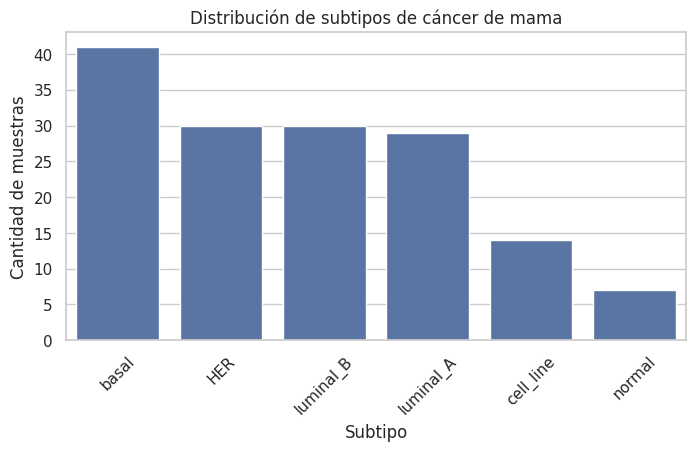

In [9]:
plt.figure(figsize=(8, 4))
sns.countplot(data=df, x='type', order=df['type'].value_counts().index)
plt.title('Distribución de subtipos de cáncer de mama')
plt.xlabel('Subtipo')
plt.ylabel('Cantidad de muestras')
plt.xticks(rotation=45)
plt.show()


### Comentario exploratorio

El dataset tiene muchas más variables que observaciones. Esto es común en datos de expresión génica, donde cada columna representa una sonda o gen. Por eso, aplicar PCA es importante para reducir dimensionalidad, disminuir ruido y evitar modelos demasiado complejos respecto al número de muestras.


## 4. Preparación de variables

La variable objetivo será `type`, que representa el subtipo/clase. Se elimina `samples` porque solo identifica la muestra y no aporta información predictiva directa.


In [10]:
target_col = 'type'
id_col = 'samples'

X = df.drop(columns=[id_col, target_col])
y = df[target_col]

print('X:', X.shape)
print('y:', y.shape)
print('Clases:', sorted(y.unique()))


X: (151, 54675)
y: (151,)
Clases: ['HER', 'basal', 'cell_line', 'luminal_A', 'luminal_B', 'normal']


## 5. Separación entrenamiento/prueba

Se usa separación estratificada para conservar aproximadamente la proporción de clases en entrenamiento y prueba.


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y
)

print('Entrenamiento:', X_train.shape)
print('Prueba:', X_test.shape)
print('\nDistribución en entrenamiento:')
print(y_train.value_counts())
print('\nDistribución en prueba:')
print(y_test.value_counts())


Entrenamiento: (120, 54675)
Prueba: (31, 54675)

Distribución en entrenamiento:
type
basal        33
luminal_B    24
HER          24
luminal_A    23
cell_line    11
normal        5
Name: count, dtype: int64

Distribución en prueba:
type
basal        8
luminal_A    6
luminal_B    6
HER          6
cell_line    3
normal       2
Name: count, dtype: int64


## 6. PCA: reducción de dimensionalidad

Antes de PCA se aplica `StandardScaler`, porque PCA depende de la escala de las variables. Luego se ajusta PCA solo con el conjunto de entrenamiento para evitar fuga de información hacia el conjunto de prueba.

Como el dataset posee 54.675 variables y solo 151 muestras, PCA permite representar la información principal en un número menor de componentes.


In [12]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Se calculan hasta 120 componentes porque el conjunto de entrenamiento tiene pocas muestras.
max_components = min(120, X_train_scaled.shape[0] - 1, X_train_scaled.shape[1])

pca_full = PCA(n_components=max_components, svd_solver='randomized', random_state=RANDOM_STATE)
pca_full.fit(X_train_scaled)

explained = pca_full.explained_variance_ratio_
cumulative_explained = np.cumsum(explained)

variance_table = pd.DataFrame({
    'PC': [f'PC{i+1}' for i in range(len(explained))],
    'varianza_explicada': explained,
    'varianza_acumulada': cumulative_explained
})

variance_table.head(10)


,PC,varianza_explicada,varianza_acumulada
0,PC1,0.117446,0.117446
1,PC2,0.102394,0.219840
2,PC3,0.054565,0.274405
3,PC4,0.034835,0.309239
4,PC5,0.031006,0.340245
5,PC6,0.029417,0.369663
6,PC7,0.020543,0.390206
7,PC8,0.019192,0.409398
8,PC9,0.016030,0.425427
9,PC10,0.015026,0.440453


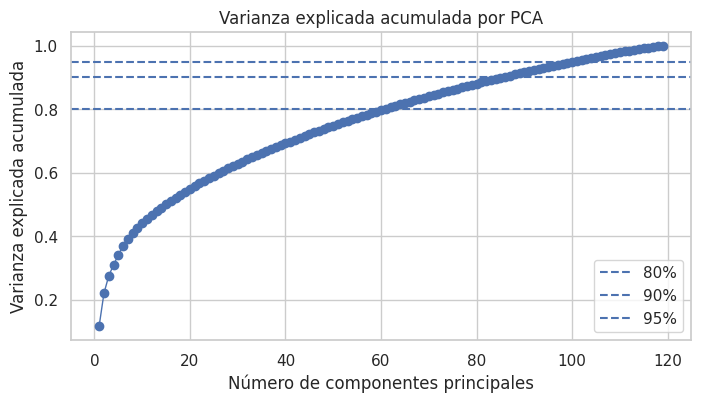

Componentes necesarios para 80% de varianza: 61
Componentes necesarios para 90% de varianza: 86
Componentes necesarios para 95% de varianza: 101


In [13]:
plt.figure(figsize=(8, 4))
plt.plot(range(1, len(cumulative_explained) + 1), cumulative_explained, marker='o', linewidth=1)
plt.axhline(0.80, linestyle='--', label='80%')
plt.axhline(0.90, linestyle='--', label='90%')
plt.axhline(0.95, linestyle='--', label='95%')
plt.title('Varianza explicada acumulada por PCA')
plt.xlabel('Número de componentes principales')
plt.ylabel('Varianza explicada acumulada')
plt.legend()
plt.show()

for threshold in [0.80, 0.90, 0.95]:
    idx = np.where(cumulative_explained >= threshold)[0]
    if len(idx) > 0:
        print(f'Componentes necesarios para {int(threshold*100)}% de varianza:', idx[0] + 1)
    else:
        print(f'Con {max_components} componentes no se alcanza {int(threshold*100)}% de varianza. Varianza acumulada máxima: {cumulative_explained[-1]:.3f}')


### Justificación de la varianza explicada seleccionada

En este trabajo se recomienda usar una varianza explicada cercana al **90%** para entrenar los modelos. La razón es que conserva gran parte de la información original, pero evita usar demasiados componentes en un dataset con pocas observaciones.

Usar 95% puede exigir una cantidad muy alta de componentes respecto al tamaño muestral, aumentando el riesgo de sobreajuste y el costo computacional. En cambio, 90% entrega un equilibrio entre conservación de información y reducción de dimensionalidad.


In [14]:
threshold_selected = 0.90
idx_selected = np.where(cumulative_explained >= threshold_selected)[0]

if len(idx_selected) > 0:
    n_components_selected = int(idx_selected[0] + 1)
else:
    n_components_selected = max_components

print('Varianza objetivo:', threshold_selected)
print('Componentes PCA seleccionados:', n_components_selected)
print('Varianza acumulada obtenida:', cumulative_explained[n_components_selected - 1])


Varianza objetivo: 0.9
Componentes PCA seleccionados: 86
Varianza acumulada obtenida: 0.9025630073406934


## 7. Visualización de los primeros componentes principales

Se proyectan las muestras sobre PC1, PC2 y PC3 para observar si existe separación visual entre subtipos.


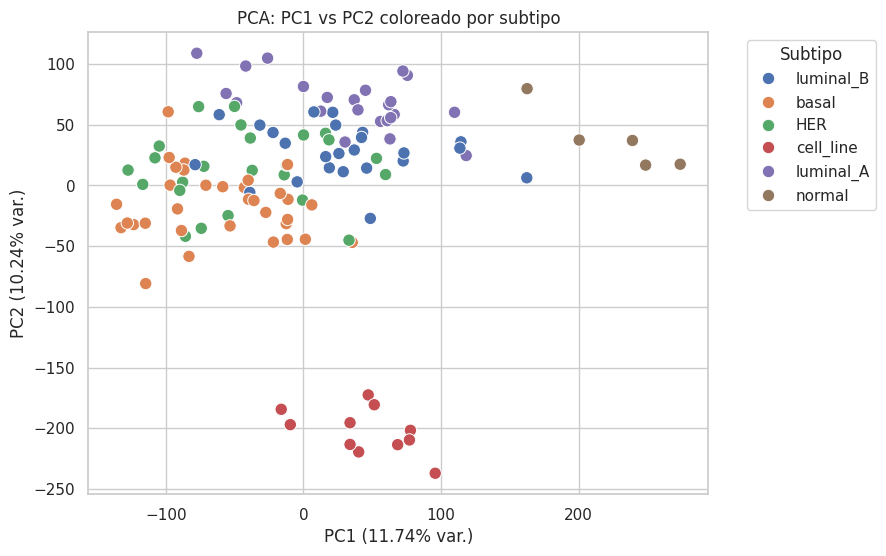

In [15]:
pca_3 = PCA(n_components=3, svd_solver='randomized', random_state=RANDOM_STATE)
X_train_pca_3 = pca_3.fit_transform(X_train_scaled)

pca_plot_df = pd.DataFrame(X_train_pca_3, columns=['PC1', 'PC2', 'PC3'])
pca_plot_df['type'] = y_train.values

plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_plot_df, x='PC1', y='PC2', hue='type', s=80)
plt.title('PCA: PC1 vs PC2 coloreado por subtipo')
plt.xlabel(f'PC1 ({pca_3.explained_variance_ratio_[0]*100:.2f}% var.)')
plt.ylabel(f'PC2 ({pca_3.explained_variance_ratio_[1]*100:.2f}% var.)')
plt.legend(title='Subtipo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


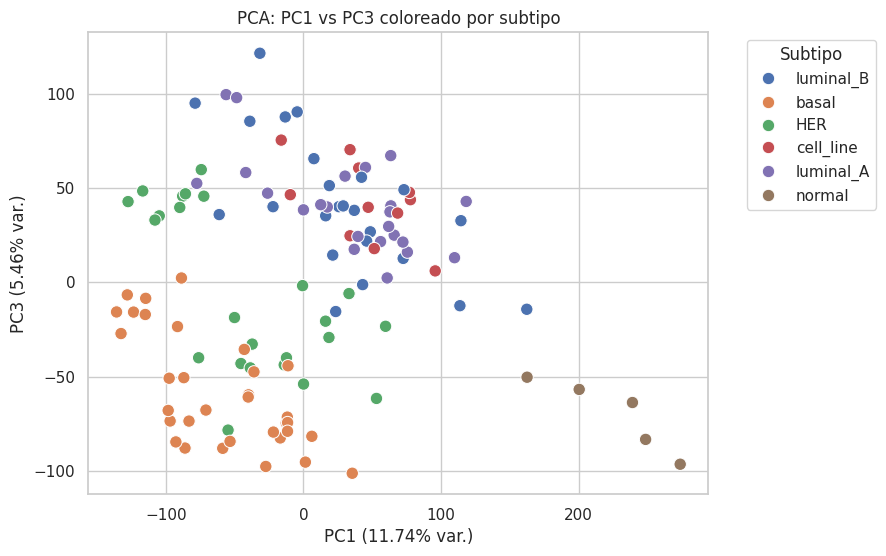

In [16]:
plt.figure(figsize=(8, 6))
sns.scatterplot(data=pca_plot_df, x='PC1', y='PC3', hue='type', s=80)
plt.title('PCA: PC1 vs PC3 coloreado por subtipo')
plt.xlabel(f'PC1 ({pca_3.explained_variance_ratio_[0]*100:.2f}% var.)')
plt.ylabel(f'PC3 ({pca_3.explained_variance_ratio_[2]*100:.2f}% var.)')
plt.legend(title='Subtipo', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


### Interpretación visual

Si los puntos de una misma clase quedan agrupados y separados de otras clases, significa que los primeros componentes capturan patrones de expresión génica útiles para diferenciar subtipos. Si existe superposición, significa que los subtipos comparten patrones similares o que se necesitan más componentes/modelos no lineales para mejorar la separación.


## 8. Loadings de los primeros componentes

Los **loadings** indican cuánto aporta cada variable original a un componente principal. En este caso, permiten identificar las sondas/gene probes que más influyen en PC1, PC2 y PC3.

Valores positivos altos indican relación directa con el componente; valores negativos altos en magnitud indican relación inversa. Para interpretar importancia se usa el valor absoluto del loading.


In [17]:
def get_top_loadings(pca_model, feature_names, component_index=0, top_n=15):
    loadings = pd.DataFrame({
        'feature': feature_names,
        'loading': pca_model.components_[component_index]
    })
    loadings['abs_loading'] = loadings['loading'].abs()
    return loadings.sort_values('abs_loading', ascending=False).head(top_n)

for component_index in range(3):
    print(f'\nTop loadings para PC{component_index + 1}')
    display(get_top_loadings(pca_3, X.columns, component_index=component_index, top_n=15))



Top loadings para PC1


,feature,loading,abs_loading
30188,220904_at,0.010709,0.010709
450,1552889_a_at,0.010580,0.010580
25394,216102_at,0.010548,0.010548
16295,206849_at,0.010448,0.010448
17684,208260_at,0.010372,0.010372
35208,225952_at,0.010273,0.010273
15565,206119_at,0.010262,0.010262
48841,239592_at,0.010257,0.010257
9192,1569393_at,0.010245,0.010245
52170,242921_at,0.010227,0.010227



Top loadings para PC2


,feature,loading,abs_loading
10243,200795_at,0.012499,0.012499
31637,222358_x_at,0.012250,0.012250
11192,201744_s_at,0.012209,0.012209
20523,211161_s_at,0.012132,0.012132
11731,202283_at,0.012114,0.012114
32400,223122_s_at,0.012099,0.012099
51242,241993_x_at,0.012083,0.012083
11341,201893_x_at,0.012039,0.012039
51026,241777_x_at,0.012037,0.012037
21204,211896_s_at,0.012024,0.012024



Top loadings para PC3


,feature,loading,abs_loading
28097,218813_s_at,0.014218,0.014218
17406,207974_s_at,0.013889,0.013889
51466,242217_s_at,0.013788,0.013788
33726,224465_s_at,0.013770,0.013770
34940,225683_x_at,0.013744,0.013744
32714,223437_at,-0.013706,0.013706
54224,35436_at,0.013666,0.013666
34688,225431_x_at,-0.013562,0.013562
12646,203198_at,0.013539,0.013539
51706,242457_at,-0.013360,0.013360


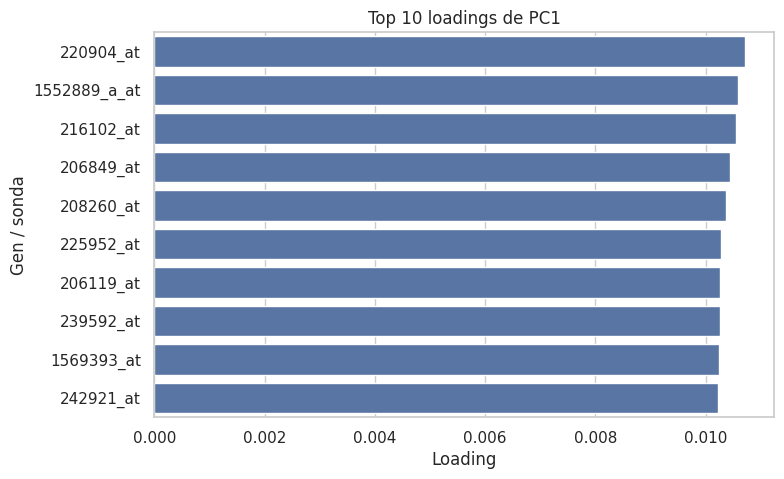

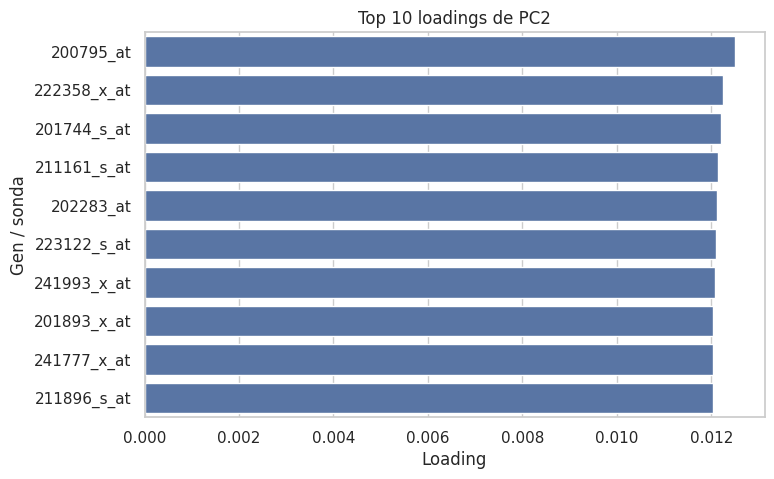

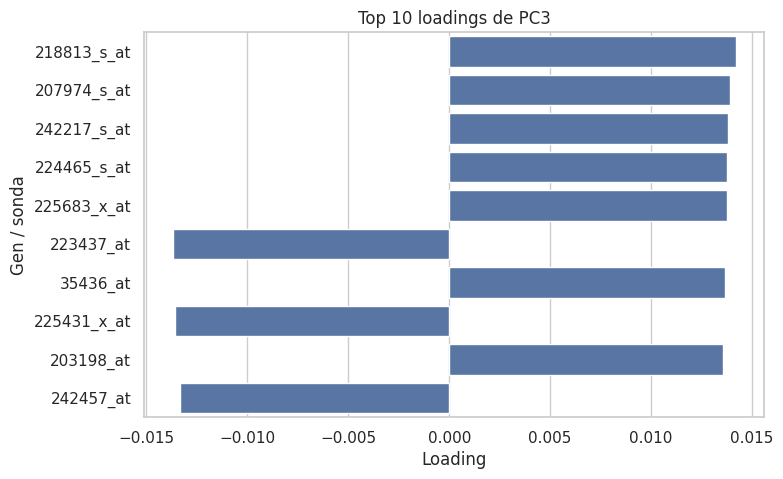

In [18]:
for component_index in range(3):
    top_load = get_top_loadings(pca_3, X.columns, component_index=component_index, top_n=10)
    plt.figure(figsize=(8, 5))
    sns.barplot(data=top_load, x='loading', y='feature')
    plt.title(f'Top 10 loadings de PC{component_index + 1}')
    plt.xlabel('Loading')
    plt.ylabel('Gen / sonda')
    plt.show()


### Interpretación de loadings

Los genes o sondas con mayor valor absoluto en PC1, PC2 y PC3 son los que más contribuyen a formar esos ejes de variación. Por ejemplo, si una sonda tiene loading positivo alto en PC1, las muestras con valores altos en esa sonda tenderán a ubicarse hacia el lado positivo de PC1. Si otra sonda tiene loading negativo alto, empujará a las muestras hacia el lado negativo del mismo componente.

Por lo tanto, los loadings permiten explicar qué variables originales están detrás de la separación observada entre subtipos en los gráficos PCA.


## 9. Modelos de clasificación con GridSearchCV

Se probarán modelos vistos en clases:

- Regresión Logística multinomial.
- K-Nearest Neighbors.
- Support Vector Machine.
- Random Forest.
- Naive Bayes Gaussiano.

La evaluación se realiza con validación cruzada estratificada y métrica `f1_macro`, adecuada cuando hay varias clases y clases desbalanceadas.


**Nota importante para GridSearchCV:** en la visualización anterior se calcula un número de componentes para justificar la varianza explicada. Sin embargo, dentro del `Pipeline` de clasificación se usa `PCA(n_components=0.95, svd_solver='full')`, porque en cada fold de validación cruzada hay menos muestras de entrenamiento. Esto evita el error de intentar usar más componentes que muestras disponibles.


In [19]:
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)

models_and_params = {
    'Logistic Regression': {
        'model': LogisticRegression(max_iter=3000, random_state=RANDOM_STATE),
        'params': {
            'clf__C': [0.01, 0.1, 1, 10],
            'clf__solver': ['lbfgs'],
            'clf__multi_class': ['auto']
        }
    },
    'KNN': {
        'model': KNeighborsClassifier(),
        'params': {
            'clf__n_neighbors': [3, 5, 7],
            'clf__weights': ['uniform', 'distance'],
            'clf__metric': ['euclidean', 'manhattan']
        }
    },
    'SVM': {
        'model': SVC(random_state=RANDOM_STATE),
        'params': {
            'clf__C': [0.1, 1, 10],
            'clf__kernel': ['linear', 'rbf'],
            'clf__gamma': ['scale']
        }
    },
    'Random Forest': {
        'model': RandomForestClassifier(random_state=RANDOM_STATE),
        'params': {
            'clf__n_estimators': [100, 200],
            'clf__max_depth': [None, 5, 10],
            'clf__min_samples_split': [2, 5]
        }
    },
    'Gaussian Naive Bayes': {
        'model': GaussianNB(),
        'params': {
            'clf__var_smoothing': [1e-9, 1e-8, 1e-7]
        }
    }
}


In [20]:
results = []
best_estimators = {}

for model_name, config in models_and_params.items():
    print(f'Entrenando modelo: {model_name}')

    pipe = Pipeline(steps=[
        ('scaler', StandardScaler()),
        ('pca', PCA(n_components=0.95, svd_solver='full')),  # PCA automático: conserva 95% de varianza y evita errores en validación cruzada
        ('clf', config['model'])
    ])

    grid = GridSearchCV(
        estimator=pipe,
        param_grid=config['params'],
        scoring='f1_macro',
        cv=cv,
        n_jobs=-1,
        verbose=0
    )

    grid.fit(X_train, y_train)
    y_pred = grid.predict(X_test)

    metrics = {
        'modelo': model_name,
        'best_cv_f1_macro': grid.best_score_,
        'accuracy_test': accuracy_score(y_test, y_pred),
        'precision_macro_test': precision_score(y_test, y_pred, average='macro', zero_division=0),
        'recall_macro_test': recall_score(y_test, y_pred, average='macro', zero_division=0),
        'f1_macro_test': f1_score(y_test, y_pred, average='macro', zero_division=0),
        'mejores_parametros': grid.best_params_
    }

    results.append(metrics)
    best_estimators[model_name] = grid.best_estimator_

results_df = pd.DataFrame(results).sort_values('f1_macro_test', ascending=False)
results_df


Entrenando modelo: Logistic Regression
Entrenando modelo: KNN
Entrenando modelo: SVM
Entrenando modelo: Random Forest
Entrenando modelo: Gaussian Naive Bayes


,modelo,best_cv_f1_macro,accuracy_test,precision_macro_test,recall_macro_test,f1_macro_test,mejores_parametros
0,Logistic Regression,0.940828,0.903226,0.924603,0.868056,0.879915,"{'clf__C': 10, 'clf__multi_class': 'auto', 'cl..."
2,SVM,0.955073,0.903226,0.924603,0.868056,0.879915,"{'clf__C': 0.1, 'clf__gamma': 'scale', 'clf__k..."
3,Random Forest,0.742718,0.774194,0.690657,0.694444,0.673684,"{'clf__max_depth': None, 'clf__min_samples_spl..."
1,KNN,0.722744,0.677419,0.705556,0.680556,0.654762,"{'clf__metric': 'euclidean', 'clf__n_neighbors..."
4,Gaussian Naive Bayes,0.619782,0.580645,0.666667,0.597222,0.578042,{'clf__var_smoothing': 1e-09}


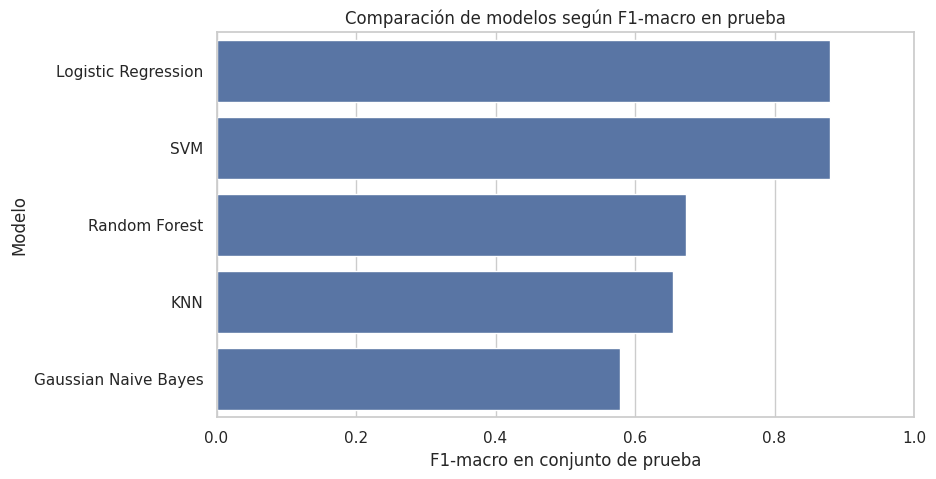

In [21]:
plt.figure(figsize=(9, 5))
sns.barplot(data=results_df, x='f1_macro_test', y='modelo')
plt.title('Comparación de modelos según F1-macro en prueba')
plt.xlabel('F1-macro en conjunto de prueba')
plt.ylabel('Modelo')
plt.xlim(0, 1)
plt.show()


## 10. Evaluación del mejor modelo

Se selecciona el modelo con mayor F1-macro en el conjunto de prueba, ya que esta métrica entrega una evaluación más equilibrada entre clases que accuracy cuando hay desbalance.


In [22]:
best_model_name = results_df.iloc[0]['modelo']
best_model = best_estimators[best_model_name]

y_pred_best = best_model.predict(X_test)

print('Mejor modelo:', best_model_name)
print('\nMejores parámetros:')
print(results_df.iloc[0]['mejores_parametros'])

print('\nReporte de clasificación:')
print(classification_report(y_test, y_pred_best, zero_division=0))


Mejor modelo: Logistic Regression

Mejores parámetros:
{'clf__C': 10, 'clf__multi_class': 'auto', 'clf__solver': 'lbfgs'}

Reporte de clasificación:
              precision    recall  f1-score   support

         HER       0.86      1.00      0.92         6
       basal       1.00      0.88      0.93         8
   cell_line       1.00      1.00      1.00         3
   luminal_A       0.83      0.83      0.83         6
   luminal_B       0.86      1.00      0.92         6
      normal       1.00      0.50      0.67         2

    accuracy                           0.90        31
   macro avg       0.92      0.87      0.88        31
weighted avg       0.91      0.90      0.90        31



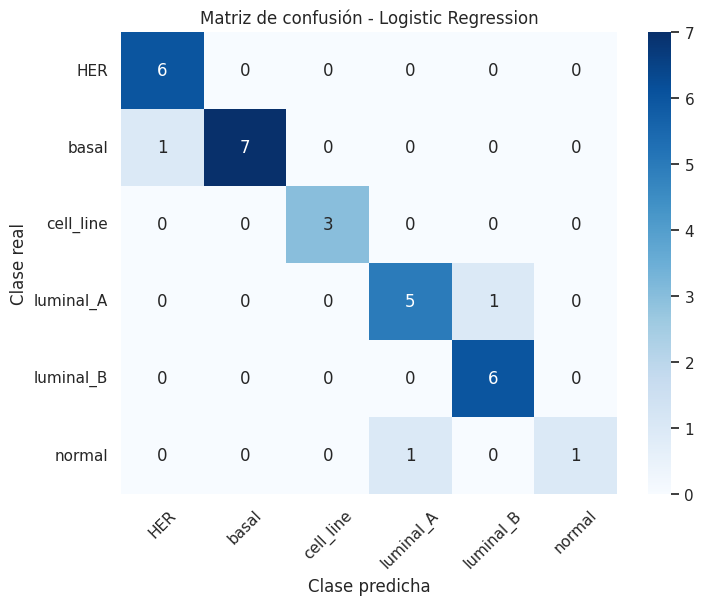

In [23]:
labels_order = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred_best, labels=labels_order)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=labels_order, yticklabels=labels_order)
plt.title(f'Matriz de confusión - {best_model_name}')
plt.xlabel('Clase predicha')
plt.ylabel('Clase real')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.show()


### Interpretación de métricas

- **Accuracy:** proporción total de predicciones correctas. Es útil, pero puede ser engañosa si las clases están desbalanceadas.
- **Precision macro:** mide qué tan confiables son las predicciones positivas de cada clase, promediando todas las clases por igual.
- **Recall macro:** mide qué proporción de casos reales de cada clase fueron detectados correctamente.
- **F1 macro:** combina precision y recall, promediando todas las clases por igual. En este problema es una métrica importante porque cada subtipo debe tener relevancia, incluso si tiene pocas muestras.
- **Matriz de confusión:** permite ver en qué subtipos el modelo se equivoca y cuáles confunde entre sí.


## 11. Interpretación final para el informe

El dataset CuMiDa presenta una estructura de alta dimensionalidad, con muchas variables génicas y pocas muestras. Por esta razón, PCA fue una etapa necesaria para reducir dimensionalidad antes de entrenar modelos supervisados.

La selección de componentes se basó en la varianza explicada acumulada. Se escogió una varianza cercana al 90% porque permite conservar gran parte de la información del dataset sin usar un número excesivo de componentes. Esto es relevante porque una cantidad muy alta de componentes en un dataset pequeño puede aumentar el riesgo de sobreajuste.

Los gráficos de PC1, PC2 y PC3 permiten observar si los subtipos presentan agrupamientos diferenciables en el espacio reducido. Además, los loadings de los primeros componentes muestran qué genes o sondas aportan más a la variabilidad principal del dataset, ayudando a interpretar biológicamente la separación entre clases.

Finalmente, se compararon distintos algoritmos mediante GridSearchCV usando F1-macro como criterio principal. Esta métrica es adecuada porque el problema tiene múltiples clases y distribución desbalanceada. El mejor modelo se selecciona según su desempeño en el conjunto de prueba, considerando accuracy, precision, recall, F1-score y matriz de confusión.


## 12. Conclusión

El flujo completo aplicado fue:

1. Carga y exploración del dataset CuMiDa.
2. Separación entre variables predictoras y clase objetivo.
3. División estratificada entre entrenamiento y prueba.
4. Estandarización de variables.
5. Aplicación e interpretación de PCA.
6. Visualización de componentes principales por clase.
7. Interpretación de loadings.
8. Entrenamiento de modelos con GridSearchCV.
9. Evaluación del mejor modelo mediante métricas de clasificación.

Este procedimiento permite clasificar subtipos de cáncer de mama de forma ordenada, justificando tanto la reducción de dimensionalidad como la selección del modelo final.
